<a href="https://colab.research.google.com/github/lucianoyllarreta/CLASE_CIENCIA_DATOS_I/blob/main/LOS%204%20FANT%C3%81STICOS/PRUEBA%20DE%20PRESENTACI%C3%93N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
upload  = files.upload()

Saving disuguaglianza-economica-globale-e-povert-1980-2024.csv to disuguaglianza-economica-globale-e-povert-1980-2024.csv


In [3]:
import pandas as pd
df = pd.read_csv('disuguaglianza-economica-globale-e-povert-1980-2024.csv')

In [4]:
### CLASIFICACIÓN GEOGRÁFICA DE LOS PAÍSES ###

# AMÉRICA
america_del_sur = ['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'Guyana', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela']
america_central_y_caribe = ['Belize', 'Costa Rica', 'El Salvador', 'Guatemala', 'Honduras','Nicaragua', 'Panama', 'Bahamas', 'Barbados', 'Cuba', 'Dominica','Dominican Republic', 'Grenada', 'Haiti', 'Jamaica', 'Saint Kitts and Nevis','Saint Lucia', 'Saint Vincent and the Grenadines', 'Trinidad and Tobago']
america_del_norte = ['Canada', 'United States', 'Mexico']

# EUROPA
europa = ['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina','Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland','France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy','Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Montenegro','Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania','Russia', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland','Ukraine', 'United Kingdom']

# ÁFRICA
africa = ['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde','Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo', 'Cote d\'Ivoire','Democratic Republic of Congo', 'Djibouti', 'Egypt', 'Equatorial Guinea', 'Eritrea','Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau','Kenya', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali','Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger','Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles','Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania','Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe']

# ASIA
asia = ['Afghanistan', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Bhutan','Brunei', 'Cambodia', 'China', 'Georgia', 'India', 'Indonesia', 'Iran','Iraq', 'Israel', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan','Laos', 'Lebanon', 'Malaysia', 'Maldives', 'Mongolia', 'Myanmar', 'Nepal','North Korea', 'Oman', 'Pakistan', 'Palestine', 'Philippines', 'Qatar','Saudi Arabia', 'Singapore', 'South Korea', 'Sri Lanka', 'Syria', 'Taiwan','Tajikistan', 'Thailand', 'Timor', 'Turkey', 'Turkmenistan','United Arab Emirates', 'Uzbekistan', 'Vietnam', 'Yemen']

# OCEANÍA
oceania = ['Australia', 'Fiji', 'Kiribati', 'Marshall Islands', 'Micronesia (country)','Nauru', 'New Zealand', 'Palau', 'Papua New Guinea', 'Samoa','Solomon Islands', 'Tonga', 'Tuvalu', 'Vanuatu']


In [5]:
# Diccionario de Colores
paleta = {
    'América del Sur': '#AEC6CF', 'América del Norte': '#FFB7B2',
    'América Central y Caribe': '#B2E2F2', 'Europa': '#B3E5BE',
    'Asia': '#FFDAC1', 'África': '#FFFFB5', 'Oceanía': '#C19AD3',
    'Argentina': '#87CEEB'
}

In [6]:
# Creamos la columna de región para facilitar el filtrado
def asignar_region(pais):
    if pais == 'Argentina': return 'Argentina'
    if pais in america_del_sur: return 'América del Sur'
    if pais in america_del_norte: return 'América del Norte'
    if pais in america_central_y_caribe: return 'América Central y Caribe'
    if pais in europa: return 'Europa'
    if pais in asia: return 'Asia'
    if pais in africa: return 'África'
    if pais in oceania: return 'Oceanía'
    return 'Otros'

df['region_final'] = df['country'].apply(asignar_region)

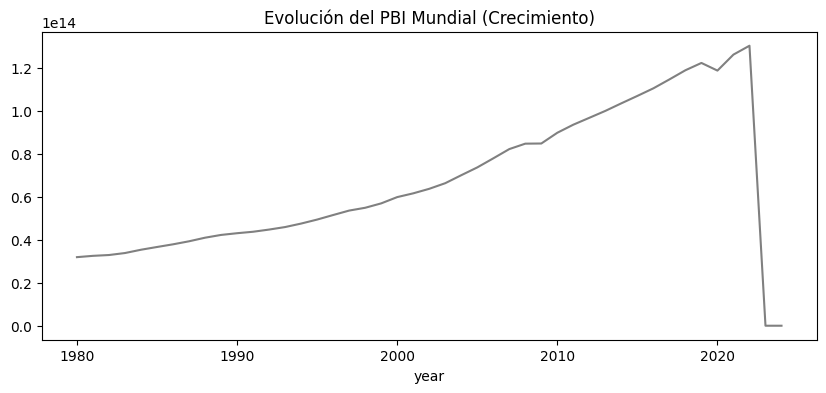

In [8]:
# --- GRÁFICO 1: EVOLUCIÓN PBI MUNDIAL (LÍNEAS) ---
df.groupby('year')['gdp'].sum().plot(kind='line', color='gray', figsize=(10,4))
plt.title("Evolución del PBI Mundial (Crecimiento)")
plt.show()

In [ ]:
# --- GRÁFICO 2: PARTICIPACIÓN POR REGIÓN + ARG (ÁREAS APILADAS) ---
# Usamos groupby para sumar el impacto por año y región
evolucion_regiones = df.groupby(['year', 'region_final'])['gdp'].sum().unstack()
evolucion_regiones.plot(kind='area', stacked=True, color=[paleta[c] for c in evolucion_regiones.columns], figsize=(12,6))
plt.title("Distribución de la Riqueza Global por Regiones y Argentina")
plt.show()

In [10]:
# ==========================================
# SECCIÓN PARA EDITAR POR CADA INTEGRANTE
# ==========================================
NOMBRE_EVENTO = "Milagro Chino" # Escribir el nombre aquí
AÑO_INICIO = 1996
AÑO_FIN = 2006
REGION_A_ANALIZAR = "Asia" # Elegir de la paleta: Asia, Europa, África, etc.
# ==========================================

# 1. Filtrado automático del periodo y región[cite: 2, 4]
df_evento = df[(df['year'] >= AÑO_INICIO) & (df['year'] <= AÑO_FIN)]
df_final = df_evento[df_evento['region_final'] == REGION_A_ANALIZAR]

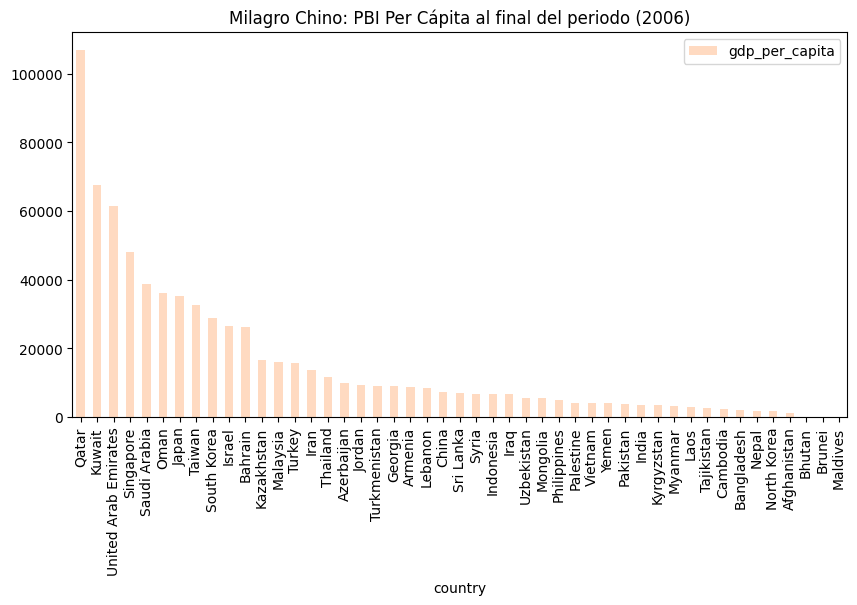

In [11]:
# --- GRÁFICO 1: RANKING DE BIENESTAR AL FINAL (BARRAS) ---
# Objetivo: Ver quién terminó mejor tras el evento[cite: 3, 5]
ranking = df_final[df_final['year'] == AÑO_FIN].sort_values('gdp_per_capita', ascending=False)
ranking.plot(kind='bar', x='country', y='gdp_per_capita', color=paleta[REGION_A_ANALIZAR], figsize=(10,5))
plt.title(f"{NOMBRE_EVENTO}: PBI Per Cápita al final del periodo ({AÑO_FIN})")
plt.show()

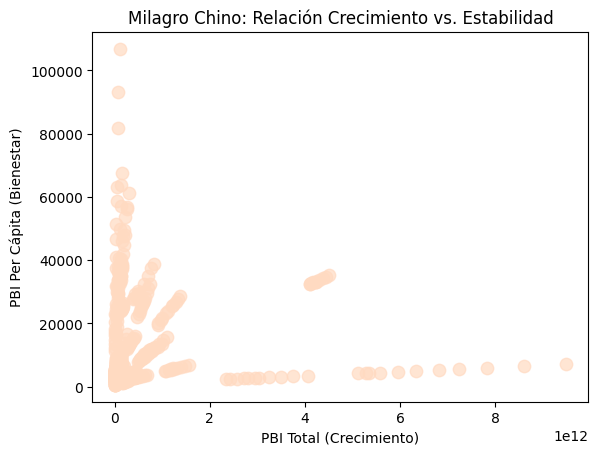

In [12]:
# --- GRÁFICO 2: CRECIMIENTO VS ESTABILIDAD (SCATTER) ---
# Objetivo: ¿El crecimiento total (PBI) trajo bienestar individual (PBI per cápita)?[cite: 3, 5]
df_final.plot(kind='scatter', x='gdp', y='gdp_per_capita', alpha=0.7, color=paleta[REGION_A_ANALIZAR], s=80)
plt.title(f"{NOMBRE_EVENTO}: Relación Crecimiento vs. Estabilidad")
plt.xlabel("PBI Total (Crecimiento)")
plt.ylabel("PBI Per Cápita (Bienestar)")
# plt.show()